In [ ]:
from typing import Callable, Optional, Sequence

import jax
import jax.numpy as jnp
from jax.typing import ArrayLike
from flax import nnx

from probjax.nn.nets.flows import AffineCouplingFlow, CouplingMLP
from functools import partial

In [2]:
# MNIST data
from datasets import load_dataset
import numpy as np

dataset = load_dataset('mnist', keep_in_memory=True)

dataset.set_format(type='numpy', columns=['image'])


In [15]:
train_data = dataset["train"]

def train_data_generator(batch_size=256):
    while True:
        idx = np.random.randint(0,len(train_data), size=batch_size)
        xs_batch = jnp.array(train_data[idx]["image"]/255, dtype=jnp.float32).reshape(batch_size, 28*28)
        yield xs_batch

datagenerator = train_data_generator()

In [16]:
p = AffineCouplingFlow(784, 10, nnx.Rngs(1), coupling_class=partial(CouplingMLP, hidden_dims=[200,200]))

params = nnx.state(p, nnx.Param)

In [17]:
def loss(params, xs):
    nnx.update(p, params)
    return -jnp.mean(p.log_prob(xs))

In [18]:
import optax

optimizer = optax.adam(1e-3)

@jax.jit
def update(params, opt_state, xs):
    loss_val, grads = jax.value_and_grad(loss)(params, xs)
    updates, opt_state = optimizer.update(grads, opt_state)
    new_params = optax.apply_updates(params, updates)
    return loss_val, new_params, opt_state

In [19]:
loss(params, next(datagenerator))

Array(7073.6562, dtype=float32)

In [20]:
opt_state = optimizer.init(params)

In [ ]:
for i in range(10):
    l = 0
    for _ in range(1000):
        xs_batch = next(datagenerator)
        loss_val, params, opt_state = update(params, opt_state,xs_batch)
        l += loss_val
    print(l/1000)

7073.5166
7073.5186
7073.519


Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x7fc5179494f0>>
Traceback (most recent call last):
  File "/mnt/qb/work/macke/mgloeckler90/miniconda3/envs/probjax/lib/python3.12/site-packages/ipykernel/ipkernel.py", line 775, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(

KeyboardInterrupt: 


7073.518
7073.519
7073.5205
7073.5195
7073.5166


KeyboardInterrupt: 

In [1]:
nnx.update(p, params)

The history saving thread hit an unexpected error (DatabaseError('database disk image is malformed')).History will not be written to the database.


NameError: name 'nnx' is not defined

In [ ]:
samples = p.sample(jax.random.PRNGKey(0), (100, ))

In [ ]:
samples.max()

Array(6.683, dtype=float32)

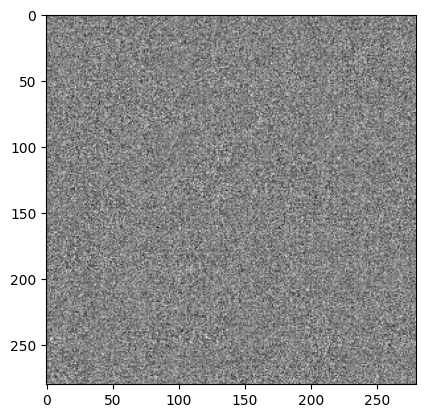

In [ ]:
import matplotlib.pyplot as plt

img = samples.reshape(10, 10, 28, 28).transpose(0, 2, 1, 3).reshape(10*28, 10*28)
plt.imshow(img, cmap="gray")